<a href="https://colab.research.google.com/github/FreddieLewin23/FreddieLewin23/blob/main/version2_sig_data_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from dataclasses import dataclass
from typing import Optional, List, Tuple, Dict


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score


import matplotlib.pyplot as plt

df = pd.read_csv('/content/Data Exercise - Trade Data.csv')
df.head() # closed trade pool for 7 traders, 120,000 rows and spot
# data looks very tidy, no missing data, dates are in the correct format
df['Date'] = pd.to_datetime(df['Date'])
df.isna().sum() # no NaNs

,0
Date,0
TimeOfDay,0
Spot,0
BuyTrader,0
SellTrader,0


Assumptions of the data:

1. I start trading as soon as the data ends here. The strategy needs to be based off of what I have in the data without overfitting (hopefully)
2. Spot price has no pattern (ie Brownian motion etc) so strategy needs to be based off of the volume data only.
3. In live trading I will not be able to see the orders of who is trading (only see at the end of the day). If I do enter into a trade then I can see who I entered into the trade with. This will rule out intra-day strategies that rely on order flow from traders that seem profitbale in the training data. When I run backtesting on strategies I need to assume I can only see spot, time and the people I enter into trades with.


Constraints of trading:
1. up to 5 buys and 5 sells (so can do less) and need to end each day flat. Short selling allowed.
2. No trades last 30 minutes of trading (weird one here). If not flat going into last 30 minutes, I need to enter into the first trades that come up towards EoD.

Ideas and Plan of Action:
1. Firstly I want to have some idea of how the other traders trade with some simple analysis.
2. You can’t target flows by ID unless you “poke” and see the counterparty. So strategies must either (i) probe to reveal IDs, or (ii) time-target windows where good traders are likely.

In [2]:
df["Date"] = pd.to_datetime(df["Date"])
try:
    df["TimeOfDay"] = pd.to_datetime(df["TimeOfDay"]).dt.time
except Exception:
    pass
dt = pd.to_datetime(df["Date"].astype(str) + " " + df["TimeOfDay"].astype(str))
df["dt"] = dt
df = df.sort_values("dt").reset_index(drop=True)
price_col = None
for cand in ["Spot", "Price", "spot", "price", "Spot_Price"]:
    if cand in df.columns:
        price_col = cand
        break
buy_col = None
sell_col = None
for cand in df.columns:
    if "buy" in cand.lower():
        buy_col = cand
    if "sell" in cand.lower():
        sell_col = cand

df["day"] = df["dt"].dt.date
df["tod"] = df["dt"].dt.time

# get trading hours window (first and last timeofday per day)
agg = df.groupby("day")["tod"].agg(["min", "max"]).reset_index()
start_t = agg["min"].mode().iloc[0]
end_t = agg["max"].mode().iloc[0]

cutoff_minutes = 30
# Compute cutoff time per day based on perday max time
# We'll approximate by subtracting 30 minutes from each day's max and then take the mode
per_day_cutoff = (df.groupby("day")["dt"].max() - pd.Timedelta(minutes=cutoff_minutes)).dt.time
cutoff_t = per_day_cutoff.mode().iloc[0]

/tmp/ipython-input-1132818001.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TimeOfDay"] = pd.to_datetime(df["TimeOfDay"]).dt.time


In [3]:
per_trader = {}
    # All trader IDs that appear anywhere
traders = pd.unique(pd.concat([df[buy_col], df[sell_col]], ignore_index=True))
traders = np.sort(traders)
# Trades where each trader appears on either side
rows = []
for tr in traders:
    buys = (df[buy_col] == tr).sum()
    sells = (df[sell_col] == tr).sum()
    total = buys + sells
    # Average timeofday (in seconds) to see if someone is early/late concentrated
    sec = df.loc[(df[buy_col] == tr) | (df[sell_col] == tr), "dt"].dt.hour * 3600 + df.loc[(df[buy_col] == tr) | (df[sell_col] == tr), "dt"].dt.minute * 60
    avg_time_sec = sec.mean() if len(sec) else np.nan
    rows.append({"Trader": tr, "Buys": buys, "Sells": sells, "Total": total, "AvgTimeSec": avg_time_sec})
per_trader_df = pd.DataFrame(rows).sort_values("Total", ascending=False).reset_index(drop=True)

per_trader_df

,Trader,Buys,Sells,Total,AvgTimeSec
0,0,46188,56763,102951,45844.403648
1,4,21113,21113,42226,45595.765642
2,2,17878,17878,35756,45367.623336
3,5,16906,16906,33812,45617.651130
4,1,7018,7018,14036,45365.407524
5,3,10570,0,10570,45532.836329
6,6,575,570,1145,36268.873362


Looks like Trader 5 is long only, maybe something like a pension fund or retail trader just wanting long term exposure, where as trader 1, 2, 3, 4, 6 are flat overall so are perhaps market makers. trader 0 is overall short so may be something like a hedge fund who are taking positions on the direction of spot.

In [4]:
vwap = df.groupby("day")[price_col].mean().rename("DayVWAP") # volume weighted average prive
# Pertrader VWAP when they BUY vs when they SELL
t_buy_vwap = df.groupby("day").apply(lambda x: x.groupby(buy_col)[price_col].mean()).rename("BuyVWAP").reset_index()
t_sell_vwap = df.groupby("day").apply(lambda x: x.groupby(sell_col)[price_col].mean()).rename("SellVWAP").reset_index()
# Merge daylevel VWAP into those
t_buy_vwap = t_buy_vwap.merge(vwap.reset_index(), on="day", how="left")
t_sell_vwap = t_sell_vwap.merge(vwap.reset_index(), on="day", how="left")
# Compute skews
t_buy_vwap["BuyMinusDayVWAP"] = t_buy_vwap["BuyVWAP"] - t_buy_vwap["DayVWAP"]
t_sell_vwap["SellMinusDayVWAP"] = t_sell_vwap["SellVWAP"] - t_sell_vwap["DayVWAP"]
# Aggregate across days
buy_edge = t_buy_vwap.groupby(t_buy_vwap.columns[1])["BuyMinusDayVWAP"].mean().rename("MeanBuySkew_vs_DayVWAP")
sell_edge = t_sell_vwap.groupby(t_sell_vwap.columns[1])["SellMinusDayVWAP"].mean().rename("MeanSellSkew_vs_DayVWAP")
# vwap_edge = pd.concat([buy_edge, sell_edge], axis=1).reset_index().rename(columns={vwap_edge.columns[0]: "Trader"})
buy_edge, sell_edge

/tmp/ipython-input-3950220791.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_buy_vwap = df.groupby("day").apply(lambda x: x.groupby(buy_col)[price_col].mean()).rename("BuyVWAP").reset_index()
/tmp/ipython-input-3950220791.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_sell_vwap = df.groupby("day").apply(lambda x: x.groupby(sell_col)[price_col].mean()).rename("SellVWAP").reset_index()


(BuyTrader
 0    0.017156
 1    0.004114
 2   -0.023379
 3    0.003429
 4   -0.013972
 5   -0.005139
 6   -0.085863
 Name: MeanBuySkew_vs_DayVWAP, dtype: float64,
 SellTrader
 0   -0.013828
 1   -0.005771
 2    0.024143
 4    0.009584
 5    0.008997
 6    0.025336
 Name: MeanSellSkew_vs_DayVWAP, dtype: float64)

In [5]:
# "Follow" vs "Fade" signal PnL proxy:
# If Trader X buys at time t and I follow (buy), close at the next trade at or after cutoff (forced EoD close)
# Similarly for sells (I sell then cover at or after cutoff).
def pnl_follow_fade(df, trader, mode="follow"):
    # mode="follow": do same side as trader
    if price_col is None or buy_col is None or sell_col is None:
        return np.nan
    # Identify cutoff per day
    day_cut = df.groupby("day")["dt"].max() - pd.Timedelta(minutes=cutoff_minutes)
    day_cut = day_cut.to_dict()
    rets = []
    for d, day_df in df.groupby("day"):
        cut_dt = day_cut[d]
        # Entry trades for this trader during the open window (before cutoff)
        t_entries = day_df[(day_df["dt"] < cut_dt) & ((day_df[buy_col] == trader) | (day_df[sell_col] == trader))]
        if t_entries.empty:
            continue
        # Exit price = first price at or after cutoff (market close-out price)
        exit_row = day_df[day_df["dt"] >= cut_dt].head(1)
        if exit_row.empty:
            continue
        exit_px = float(exit_row[price_col].iloc[0])
        # For each entry, compute PnL for 1-share
        for _, row in t_entries.iterrows():
            side = "buy" if row[buy_col] == trader else "sell"
            entry_px = float(row[price_col])
            if mode == "follow":
                # Do same side
                if side == "buy":
                    pnl = exit_px - entry_px
                else:
                    pnl = entry_px - exit_px
            else:  # fade
                # Do opposite side
                if side == "buy":
                    pnl = entry_px - exit_px
                else:
                    pnl = exit_px - entry_px
            rets.append(pnl)
    if len(rets) == 0:
        return np.nan
    return pd.Series(rets).mean(), pd.Series(rets).std(), len(rets)

In [6]:
ff_rows = []
for tr in per_trader_df["Trader"]:
    res_fol = pnl_follow_fade(df, tr, mode="follow")
    res_fade = pnl_follow_fade(df, tr, mode="fade")
    fol_mean, fol_std, fol_n = (res_fol if isinstance(res_fol, tuple) else (np.nan, np.nan, 0))
    fad_mean, fad_std, fad_n = (res_fade if isinstance(res_fade, tuple) else (np.nan, np.nan, 0))
    ff_rows.append({
        "Trader": tr,
        "Follow_meanPnL": fol_mean,
        "Follow_std": fol_std,
        "Follow_trades": fol_n,
        "Fade_meanPnL": fad_mean,
        "Fade_std": fad_std,
        "Fade_trades": fad_n
    })
ff_df = pd.DataFrame(ff_rows).sort_values("Follow_meanPnL", ascending=False).reset_index(drop=True)

we can see here that trader 6 is clearly quite profitable (on average) but doesnt have many trades. when we poke the traders, ideally wed see we are following trader 6 but that we will rare. if not, wed see we are following trader 2. clearly we want to avoid trader 0 and 1. if we get into a trade following trader 0 or 1 then i want to close that exposure as soon as possible (next price).

So what are we even looking at here, trader 6 stands out
Mean + 0.099450 on a per-trade basis vs σ around 0.78 means Sharpe of  0.13, which is enormous at the per-trade level given that each trade is big and the sample size is 1145 so big ish.

I want to follow Trader 6s trades (same-side) to the cutoff.
Traders 245 are consistent
Trader 3 is basically flat meaning neutral so maybe liquidity provision.
Traders 1 and 0 are consistently negative when followed. I dont want to follow them if I run a follwowing strategy

Fading them yields a mirror +0.010 to +0.018 edge per trade.
Trader 0 has large volume (102951 trades). If this was a proper market theyd have big influenc slippage wise (largest volume) if you were trading around them.

First strategy I want to test now we have this data:

Whitelist is {6, 2, 4, 5}
Blacklist is {0, 1}

Probe: take the first buy (or sell) opportunity each hour (max 2–3 pokes/day so we respect the 10-trade cap).

If counterparty is in the Whitelist: follow that trader same-side for up to N extra trades that day (e.g., N=2), but never exceed 5 buys/5 sells.

If counterparty is in Blacklist: scratch quickly (close next available opposite-side print within, say, 5 minutes) and avoid further trades in that direction that hour.

I want to check whether want i found above is consistent throughout the year of trading. once i have checked that I will backtest this idea. I do want to use some 'cooler' maths at some point. One idea I had was to use a hidden markov model with regimes where trader 6 is profitbale, trader 2 trader 4. if a HMM could pick up regime changes between when traders are working well vs not well, when i poke them to find the counterparty if they are regime then follow them, if not then carry on and get out at the next trade to not get exposure when they arent profitbale. (oh and counterparty risk isnt mentioned at all, i assume we are trading listed products so counterparty risk isnt a worry. if it was OTC maybe wed include some sort of Credit value adjustment if they arent a great counterparty).

In [7]:
df["day"] = df["dt"].dt.date
df["month"] = df["dt"].dt.to_period("M").astype(str)

price_col = "Spot" if "Spot" in df.columns else ("Price" if "Price" in df.columns else None)
buy_col = "BuyTrader" if "BuyTrader" in df.columns else [c for c in df.columns if "buy" in c.lower()][0]
sell_col = "SellTrader" if "SellTrader" in df.columns else [c for c in df.columns if "sell" in c.lower()][0]

def monthly_ff(df):
    day_cut_dt = df.groupby("day")["dt"].max() - pd.Timedelta(minutes=cutoff_minutes)
    day_cut_dt = day_cut_dt.to_dict()
    results = []

    for d, day_df in df.groupby("day"):
        if d not in day_cut_dt:
            continue
        cut_dt = day_cut_dt[d]
        exit_row = day_df[day_df["dt"] >= cut_dt].head(1)
        if exit_row.empty:
            continue
        exit_px = float(exit_row[price_col].iloc[0])
        open_df = day_df[day_df["dt"] < cut_dt]
        for _, row in open_df.iterrows():
            entry_px = float(row[price_col])
            buyer = row[buy_col]
            seller = row[sell_col]
            # Buyer follow/fade
            pnl_follow_buy = exit_px - entry_px
            pnl_fade_buy = entry_px - exit_px
            results.append({"Trader": buyer, "Side": "buy", "day": d, "FollowPnL": pnl_follow_buy, "FadePnL": pnl_fade_buy})
            # Seller follow/fade
            pnl_follow_sell = entry_px - exit_px
            pnl_fade_sell = exit_px - entry_px
            results.append({"Trader": seller, "Side": "sell", "day": d, "FollowPnL": pnl_follow_sell, "FadePnL": pnl_fade_sell})

    res_df = pd.DataFrame(results)
    res_df["month"] = pd.to_datetime(res_df["day"]).dt.to_period("M").astype(str)
    summary = res_df.groupby(["month", "Trader"])[["FollowPnL", "FadePnL"]].mean().reset_index()
    return summary

monthly_ff_df = monthly_ff(df)


In [8]:
monthly_ff_df

,month,Trader,FollowPnL,FadePnL
0,2022-01,0,-0.015467,0.015467
1,2022-01,1,0.002289,-0.002289
2,2022-01,2,0.049050,-0.049050
3,2022-01,3,-0.063153,0.063153
4,2022-01,4,0.008862,-0.008862
...,...,...,...,...
79,2022-12,2,0.052886,-0.052886
80,2022-12,3,0.007233,-0.007233
81,2022-12,4,-0.040025,0.040025
82,2022-12,5,-0.012354,0.012354


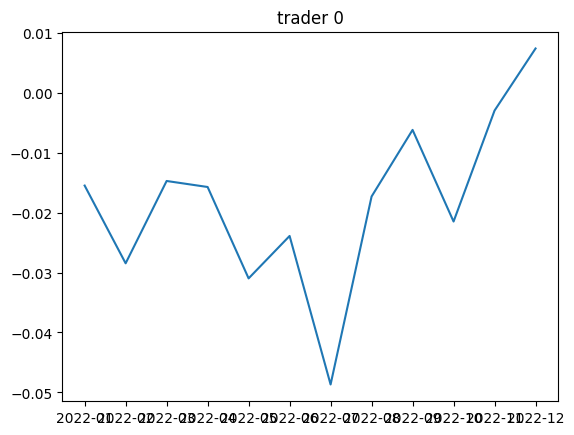

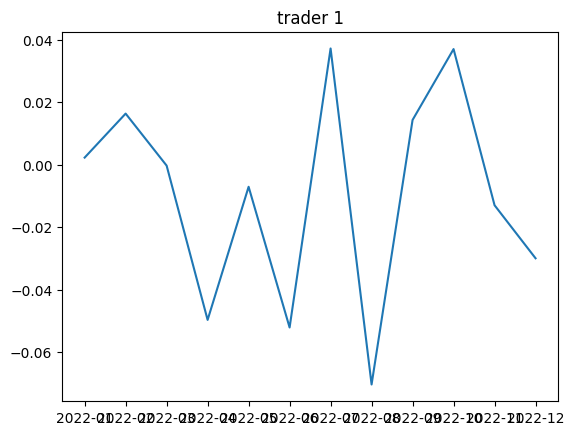

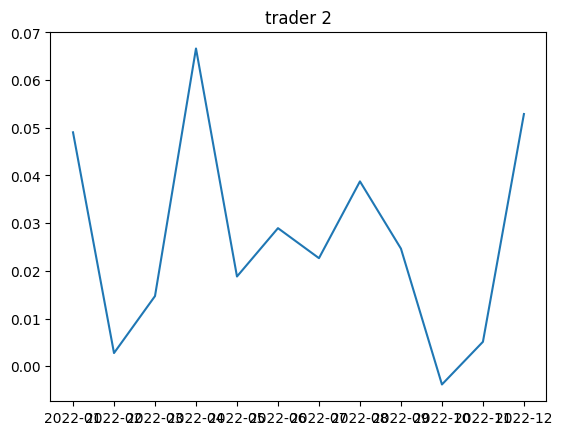

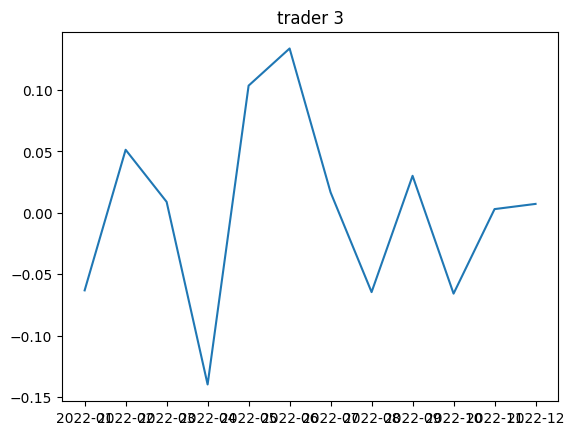

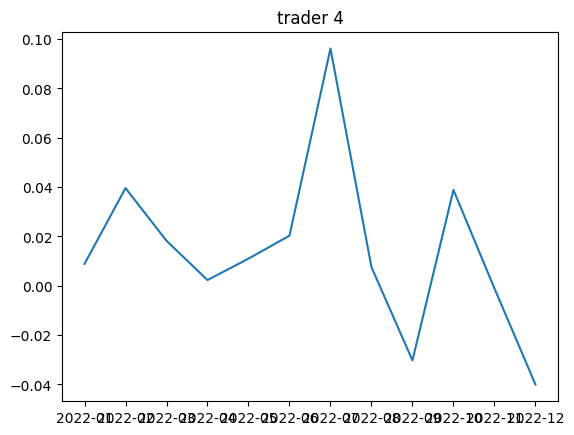

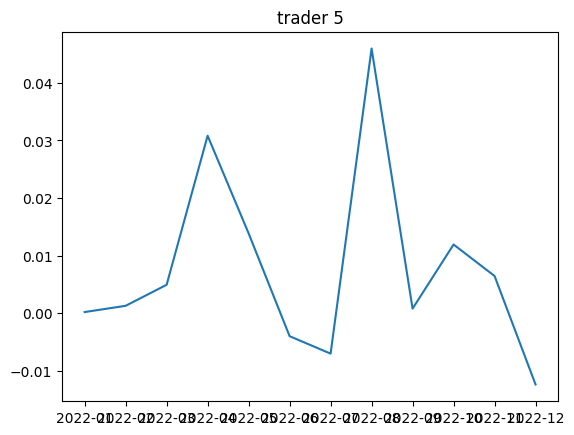

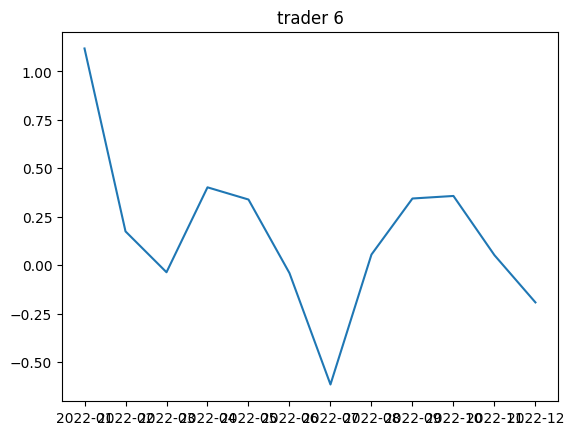

In [9]:
monthly_ff_df # 84 rows since 12 months * 7 trader
monthly_ff_df.iloc[::7, :]
monthly_ff_df.iloc[1::7, :]
plt.plot(monthly_ff_df.iloc[::7, :]['month'], monthly_ff_df.iloc[::7, :]['FollowPnL'])
plt.title('trader 0')
plt.show()
plt.plot(monthly_ff_df.iloc[1::7, :]['month'], monthly_ff_df.iloc[1::7, :]['FollowPnL'])
plt.title('trader 1')
plt.show()
plt.plot(monthly_ff_df.iloc[2::7, :]['month'], monthly_ff_df.iloc[2::7, :]['FollowPnL'])
plt.title('trader 2')
plt.show()
plt.plot(monthly_ff_df.iloc[3::7, :]['month'], monthly_ff_df.iloc[3::7, :]['FollowPnL'])
plt.title('trader 3')
plt.show()
plt.plot(monthly_ff_df.iloc[4::7, :]['month'], monthly_ff_df.iloc[4::7, :]['FollowPnL'])
plt.title('trader 4')
plt.show()
plt.plot(monthly_ff_df.iloc[5::7, :]['month'], monthly_ff_df.iloc[5::7, :]['FollowPnL'])
plt.title('trader 5')
plt.show()
plt.plot(monthly_ff_df.iloc[6::7, :]['month'], monthly_ff_df.iloc[6::7, :]['FollowPnL'])
plt.title('trader 6')
plt.show()

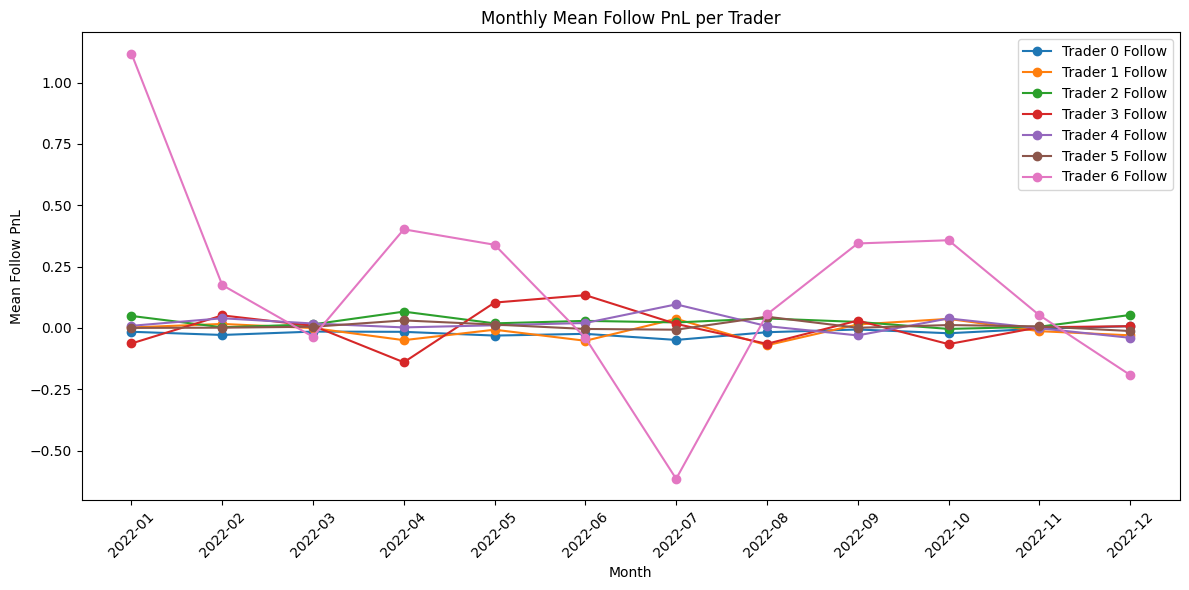

In [10]:
traders = sorted(monthly_ff_df["Trader"].unique())
plt.figure(figsize=(12, 6))
for tr in traders:
    sub = monthly_ff_df[monthly_ff_df["Trader"] == tr]
    plt.plot(sub["month"], sub["FollowPnL"], marker="o", label=f"Trader {tr} Follow")
plt.title("Monthly Mean Follow PnL per Trader")
plt.xlabel("Month")
plt.ylabel("Mean Follow PnL")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

we can see here that trader 6 does very well in some periods, but also the worst in other when they are doing badly (volatile returns on six). if i can somehow classify when trader 6 is doing well, follow them when they are. if not, i want to follow trader 2 since they are quite consistently profitable.

Strategy Idea:
1. use statistical classification (logistic regression, features i need to work out) to find when 6 is trading well. when 6 is trading well, 'poke' the market, find trader 6s position and follow them. if they are not trading well either fade them or trade with 2 as the person i want to poke and follow.

Protocol
Split by month (e.g., Jan–Aug train, Sep–Dec test) to mimic forward deployment. compute all features from data up to t only. Calibrate the probability , so p = P(y=1 | x) is meaningful. Pick a probability threshold that maximizes expected PnL under trade cap

In [12]:



# =========================
# CONFIG
# =========================
CSV_PATH = "/content/Data Exercise - Trade Data.csv"
PRICE_COL_CANDIDATES = ["Spot", "Price", "spot", "price", "Spot_Price"]
BUY_TRADER_CANDIDATES = ["BuyTrader"]
SELL_TRADER_CANDIDATES = ["SellTrader"]
TIME_COL_CANDIDATES = ["TimeOfDay", "time", "Time"]
DATE_COL = "Date"


# Trading constraints
LAST_MINUTES_CUTOFF = 30 # no new entries inside last 30 minutes
MAX_BUYS_PER_DAY = 5 # entris cap, not exits
MAX_SELLS_PER_DAY = 5 # entries cap, not exits
POKE_INTERVAL_SEC = 45*60 # poke every 45 minutes
FIRST_POKE_OFFSET_MIN = 15 # first poke 15 min after open, and 45 * 8 means 7.66 hours later we are out of pokes


# TP/SL scaling
RV_FALLBACK = 0.001 # if rv_300s is NaN/0, fallback vol
TP_K = 6.0 # Takeprofit = +K * rv_300s_at_entry
SL_K = 6.0 # Stoploss = -K * rv_300s_at_entry (negative)
TIME_STOP_SEC = 20*60 # time stop in seconds


# Walkforward months (1..12). We'll train on months < m and trade month m.
TRAIN_END_MONTH = 8 # classic split: train Jan–Aug
TRADE_MONTHS = [9,10,11,12] # OOS: Sep–Dec


# Feature sets
FEAT_COLS_BASE = [
"ret_60s", "ret_300s", "ret_900s", "rv_300s", "rate_60s",
"dist_to_vwap", "dist_to_high", "dist_to_low", "pos_in_day"
]
FEAT_COLS_TRAIN = FEAT_COLS_BASE + ["is_buyer"]

In [13]:
df = pd.read_csv(CSV_PATH)
# Robust date
df[DATE_COL] = pd.to_datetime(df[DATE_COL])


# Find time column if present
_time_col = None
for c in TIME_COL_CANDIDATES:
    if c in df.columns:
        _time_col = c
        break

# make sure the dates are in the correct format
if _time_col is not None:
    try:
        df[_time_col] = pd.to_datetime(df[_time_col]).dt.time
    except Exception:
    # If already HH:MM:SS strings, fine
        pass
    df["dt"] = pd.to_datetime(df[DATE_COL].astype(str) + " " + df[_time_col].astype(str))
else:
    df["dt"] = df[DATE_COL]


# idenify price/trader columns
price_col = None
for c in PRICE_COL_CANDIDATES:
    if c in df.columns:
        price_col = c; break
if price_col is None:
    raise ValueError("hello:::: PRICE_COL_CANDIDATES not set correctly.")


buy_col = None
for c in BUY_TRADER_CANDIDATES:
    if c in df.columns:
        buy_col = c; break
if buy_col is None:
# fallback heuristic
    for c in df.columns:
        if "buy" in c.lower():
            buy_col = c; break
if buy_col is None:
    raise ValueError("column not found")


sell_col = None
for c in SELL_TRADER_CANDIDATES:
    if c in df.columns:
        sell_col = c; break
if sell_col is None:
    for c in df.columns:
        if "sell" in c.lower():
            sell_col = c; break
if sell_col is None:
    raise ValueError("column not found")


df = df.sort_values("dt").reset_index(drop=True)
df["day"] = df["dt"].dt.date
df["month"] = df["dt"].dt.month

/tmp/ipython-input-1378780455.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[_time_col] = pd.to_datetime(df[_time_col]).dt.time


In [16]:
def build_features_per_day(g: pd.DataFrame) -> pd.DataFrame:
    g = g.copy().set_index("dt").sort_index()
    px = g[price_col].astype(float)


    # Rolling returns (causal)
    g["ret_60s"] = px.pct_change().rolling("60s").sum()
    g["ret_300s"] = px.pct_change().rolling("300s").sum()
    g["ret_900s"] = px.pct_change().rolling("900s").sum()


    # Realized vol (std of 5s returns over 5 minutes)
    r5 = px.pct_change().rolling("5s").sum()
    g["rv_300s"] = r5.rolling("300s").std()


    # Print rate in last 60s (count of prints)
    g["rate_60s"] = px.rolling("60s").count()


    # Running intraday VWAP proxy (equal-weighted mean)
    g["cum_mean"] = px.expanding().mean()
    g["dist_to_vwap"] = (px - g["cum_mean"]) / g["cum_mean"]


    # High/low so far
    g["day_high_sofar"] = px.cummax()
    g["day_low_sofar"] = px.cummin()
    g["dist_to_high"] = (g["day_high_sofar"] - px) / px
    g["dist_to_low"] = (px - g["day_low_sofar"]) / px


    # Position in day (0..1)
    start, end = g.index.min(), g.index.max()
    total = (end - start).total_seconds() if pd.notna(end) and pd.notna(start) else 1.0
    g["pos_in_day"] = (g.index - start).total_seconds() / max(total, 1.0)
    return g.reset_index()




df_feat = df.groupby("day", group_keys=False).apply(build_features_per_day)

day_last_dt = df_feat.groupby("day")["dt"].max()
day_cut_dt: Dict[pd.Timestamp, pd.Timestamp] = (day_last_dt - pd.Timedelta(minutes=LAST_MINUTES_CUTOFF)).to_dict()
df_feat.head()


/tmp/ipython-input-18937008.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_feat = df.groupby("day", group_keys=False).apply(build_features_per_day)


,dt,Date,TimeOfDay,Spot,BuyTrader,SellTrader,day,month,ret_60s,ret_300s,ret_900s,rv_300s,rate_60s,cum_mean,dist_to_vwap,day_high_sofar,day_low_sofar,dist_to_high,dist_to_low,pos_in_day
0,2022-01-03 09:32:05,2022-01-03,09:32:05,99.96,3,0,2022-01-03,1,NaN,NaN,NaN,NaN,1.0,99.9600,0.000000e+00,99.96,99.96,0.000000,0.0000,0.000000
1,2022-01-03 09:34:11,2022-01-03,09:34:11,99.98,4,5,2022-01-03,1,2.000800e-04,2.000800e-04,2.000800e-04,NaN,1.0,99.9700,1.000300e-04,99.98,99.96,0.000000,0.0002,0.005435
2,2022-01-03 09:34:29,2022-01-03,09:34:29,99.97,4,5,2022-01-03,1,1.000600e-04,1.000600e-04,1.000600e-04,0.000212,2.0,99.9700,1.421512e-16,99.98,99.96,0.000100,0.0001,0.006212
3,2022-01-03 09:34:44,2022-01-03,09:34:44,99.96,4,0,2022-01-03,1,3.001901e-08,3.001901e-08,3.001901e-08,0.000173,3.0,99.9675,-7.502438e-05,99.98,99.96,0.000200,0.0000,0.006859
4,2022-01-03 09:39:02,2022-01-03,09:39:02,99.88,3,1,2022-01-03,1,-8.003201e-04,-8.002901e-04,-8.002901e-04,0.000424,1.0,99.9500,-7.003502e-04,99.98,99.88,0.001001,0.0000,0.017989


In [17]:
def build_labels_for_trader(df_feat: pd.DataFrame, trader_id: int) -> pd.DataFrame:
    rows = []
    for d, g in df_feat.groupby("day"):
        if d not in day_cut_dt:
            continue
        cut_dt = day_cut_dt[d]
        # Exit price at/after cutoff
        exit_row = g[g["dt"] >= cut_dt].head(1)
        if exit_row.empty:
            continue
        exit_px = float(exit_row[price_col].iloc[0])
        open_g = g[g["dt"] < cut_dt].copy()
        mask = (open_g[buy_col] == trader_id) | (open_g[sell_col] == trader_id)
        tg = open_g[mask].copy()
        if tg.empty:
            continue
        is_buyer = (tg[buy_col] == trader_id).astype(int)
        entry_px = tg[price_col].astype(float)
        pnl_follow = np.where(is_buyer == 1, exit_px - entry_px, entry_px - exit_px)
        X = tg[["dt", "day", "month"] + FEAT_COLS_BASE].copy()
        X["pnl_follow"] = pnl_follow
        X["y"] = (pnl_follow >= 0.0).astype(int)
        X["is_buyer"] = is_buyer
        rows.append(X)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [18]:
def make_logit_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(max_iter=250))
    ])

In [19]:
def fit_classifier(train_df: pd.DataFrame) -> Optional[Pipeline]:
    if train_df.empty:
        return None
    X = train_df[FEAT_COLS_TRAIN].values
    y = train_df["y"].values
    pipe = make_logit_pipeline()
    pipe.fit(X, y)
    return pipe

def tau_from_train(train_df: pd.DataFrame, clf: Optional[Pipeline]) -> float:
    if clf is None or train_df.empty:
        return 0.5
    X = train_df[FEAT_COLS_TRAIN].values
    p = clf.predict_proba(X)[:, 1]
    r_plus = float(train_df.loc[train_df["y"] == 1, "pnl_follow"].mean())
    r_minus = float(train_df.loc[train_df["y"] == 0, "pnl_follow"].mean())
    if (r_plus - r_minus) == 0 or np.isnan(r_plus) or np.isnan(r_minus):
        tau = 0.5
    else:
        tau = max(0.0, min(1.0, (-r_minus) / (r_plus - r_minus)))
    # Floor by probability percentile to avoid too-low thresholds in noisy cases
    tau_floor = float(np.nanpercentile(p, 70)) if len(p) > 0 else 0.5
    return max(tau, tau_floor)

def auc_of(clf: Optional[Pipeline], d: pd.DataFrame) -> float:
    if clf is None or d.empty:
        return np.nan
    try:
        X = d[FEAT_COLS_TRAIN].values
        y = d["y"].values
        p = clf.predict_proba(X)[:, 1]
        return float(roc_auc_score(y, p))
    except Exception:
        return np.nan

In [21]:
labels_6 = build_labels_for_trader(df_feat, 6)
labels_2 = build_labels_for_trader(df_feat, 2)

@dataclass
class Position:
    side: str # "long" or "short"
    entry_dt: pd.Timestamp
    entry_px: float
    trader: Optional[int] # 6, 2, or None for poke/scratch
    rv_at_entry: float
    tp_px: float
    sl_px: float

def score_trader_row(row: pd.Series, trader_id: int, clf: Optional[Pipeline]) -> Tuple[Optional[float], Optional[str]]:
    if clf is None:
        return None, None
    x = row[FEAT_COLS_BASE].astype(float).values.reshape(1, -1)
    is_buyer = 1 if row[buy_col] == trader_id else 0
    xv = np.concatenate([x, np.array([[is_buyer]])], axis=1)
    p = clf.predict_proba(xv)[:, 1][0]
    side = "buy" if is_buyer == 1 else "sell"
    return p, side


def vol_scaled_targets(rv_val: float, entry_px: float) -> Tuple[float, float]:
    rv = rv_val if pd.notna(rv_val) and rv_val > 0 else RV_FALLBACK
    tp = entry_px + TP_K * rv
    sl = entry_px - SL_K * rv
    return tp, sl

def manage_positions(entries: List[Position], current_dt, current_px, cut_dt) -> Tuple[List[Position], List[dict]]:
    closed = []
    still_open = []
    for pos in entries:
        pnl_now = (current_px - pos.entry_px) if pos.side == "long" else (pos.entry_px - current_px)
        elapsed = (current_dt - pos.entry_dt).total_seconds()
        # Check TP/SL using price levels
        hit_tp = (current_px >= pos.tp_px) if pos.side == "long" else (current_px <= pos.sl_px) # note: sl_px stores negative shift for short? we used symmetric; use pnl conditions instead for robustness
        hit_sl = (current_px <= pos.sl_px) if pos.side == "long" else (current_px >= pos.tp_px)
        # Use pnl-based check to be safe
        hit_tp = hit_tp or (pnl_now >= TP_K * (pos.rv_at_entry if pos.rv_at_entry>0 else RV_FALLBACK))
        hit_sl = hit_sl or (pnl_now <= -SL_K * (pos.rv_at_entry if pos.rv_at_entry>0 else RV_FALLBACK))


        hit_time = (elapsed >= TIME_STOP_SEC)
        hit_cut = (current_dt >= cut_dt)
        if hit_tp or hit_sl or hit_time or hit_cut:
            closed.append({
        "entry_dt": pos.entry_dt, "exit_dt": current_dt, "side": pos.side,
        "entry_px": pos.entry_px, "exit_px": current_px, "trader": pos.trader,
        "reason": "TP/SL/time/cutoff"
        })
        else:
            still_open.append(pos)
    return still_open, closed



In [22]:
bt_rows = []


for m in TRADE_MONTHS:
    # Build training sets up to prev month
    train6 = labels_6[(labels_6["month"] < m)].dropna(subset=FEAT_COLS_TRAIN + ["y", "pnl_follow"])
    train2 = labels_2[(labels_2["month"] < m)].dropna(subset=FEAT_COLS_TRAIN + ["y", "pnl_follow"])


    # Fit per-trader models
    clf6 = fit_classifier(train6)
    clf2 = fit_classifier(train2)


    # Thresholds from their respective train windows
    tau6 = tau_from_train(train6, clf6) if clf6 else 0.5
    tau2 = tau_from_train(train2, clf2) if clf2 else 0.5


    # Trade only month m
    for d, g in df_feat[df_feat["month"] == m].groupby("day"):
        if d not in day_cut_dt:
            continue
        cut_dt = day_cut_dt[d]
        day_first_dt = g["dt"].min()


        # Schedule pokes
        poke_times = []
        t = day_first_dt + pd.Timedelta(minutes=FIRST_POKE_OFFSET_MIN)
        while t < (cut_dt - pd.Timedelta(minutes=1)):
            poke_times.append(t)
            t += pd.Timedelta(seconds=POKE_INTERVAL_SEC)


        buys_used = 0
        sells_used = 0
        entries: List[Position] = []
        next_poke_idx = 0


        g = g.sort_values("dt").copy()
        for _, row in g.iterrows():
            dt = row["dt"]
            if dt < day_first_dt:
                continue
            px = float(row[price_col])


            # 1) Manage existing positions
            entries, closed_now = manage_positions(entries, dt, px, cut_dt)
            for c in closed_now:
                pnl = (c["exit_px"] - c["entry_px"]) if c["side"] == "long" else (c["entry_px"] - c["exit_px"])
                bt_rows.append({**c, "pnl": pnl})


            # 2) No new entries inside last 30 min
            if dt >= cut_dt:
                continue


            # 3) Poke condition
            should_poke = (next_poke_idx < len(poke_times)) and (dt >= poke_times[next_poke_idx])
            if not should_poke:
                continue
            next_poke_idx += 1
            # Must have entry capacity available
            if (buys_used >= MAX_BUYS_PER_DAY) and (sells_used >= MAX_SELLS_PER_DAY):
                continue

            # poke: choose a direction that guarantees a fill proxy
            # we mirror the immediate row participation side (if buyer present, we sell into it)
            # Simple rule: if this row has a buyer, we SELL (open short) otherwisee if it has a seller we BUY
            # we trade 1u and learn counterparties on this price we see
            has_buyer = pd.notna(row[buy_col])
            has_seller = pd.notna(row[sell_col])

            poke_side = None
            if has_buyer and sells_used < MAX_SELLS_PER_DAY:
                poke_side = "short" # we sell into a buyer
            elif has_seller and buys_used < MAX_BUYS_PER_DAY:
                poke_side = "long" # we buy from a seller
            else:
            # No capacity on that side; skip this poke
                continue

            rv_here = float(row.get("rv_300s", np.nan))
            tp_px, sl_px = vol_scaled_targets(rv_here, px)
            entries.append(Position(
                side=poke_side,
                entry_dt=dt,
                entry_px=px,
                trader=None, # set to 6/2 if we keep
                rv_at_entry=rv_here if pd.notna(rv_here) else RV_FALLBACK,
                tp_px=tp_px,
                sl_px=sl_px,
            ))
            if poke_side == "long":
                buys_used += 1
            else:
                sells_used += 1

            revealed_id = None
            if (row[buy_col] == 6) or (row[sell_col] == 6):
                revealed_id = 6
            elif (row[buy_col] == 2) or (row[sell_col] == 2):
                revealed_id = 2


            keep = False
            if revealed_id == 6 and clf6 is not None:
                p6, side6 = score_trader_row(row, 6, clf6)
                # keep if model high enough and direction aligns: if counterparty is BUY, our long would align; if counterparty is SELL, our short aligns
                if p6 is not None and p6 >= tau6:
                # Align sides: if row shows trader6 as buyer, "follow" means we should be long
                    if side6 == "buy" and poke_side == "long":
                        keep = True
                    if side6 == "sell" and poke_side == "short":
                        keep = True
                if keep:
                    entries[-1].trader = 6
            elif revealed_id == 2 and clf2 is not None:
                p2, side2 = score_trader_row(row, 2, clf2)
                if p2 is not None and p2 >= tau2:
                    if side2 == "buy" and poke_side == "long":
                        keep = True
                    if side2 == "sell" and poke_side == "short":
                        keep = True
                if keep:
                    entries[-1].trader = 2

            if not keep:
                # Immediate scratch at the next tick (here: same dt acts as immediate
                # we let it close on the very next iteration's price, add here by recording a scratch with current px).
                # To be conservative, record a minimal round-trip at this price (near 0 PnL) and pay costs.
                scratch_pos = entries.pop()
                pnl_raw = (px - scratch_pos.entry_px) if scratch_pos.side == "long" else (scratch_pos.entry_px - px)
                bt_rows.append({
                    "day": d, "entry_dt": scratch_pos.entry_dt, "exit_dt": dt, "side": scratch_pos.side,
                    "entry_px": scratch_pos.entry_px, "exit_px": px, "trader": "scratch", "reason": "scratch", "pnl": pnl_raw
                })
        exit_row = g[g["dt"] >= cut_dt].head(1)
        if not exit_row.empty:
            exit_dt = exit_row["dt"].iloc[0]
            exit_px = float(exit_row[price_col].iloc[0])
            for pos in entries:
                pnl_raw = (exit_px - pos.entry_px) if pos.side == "long" else (pos.entry_px - exit_px)
                bt_rows.append({
                    "day": d, "entry_dt": pos.entry_dt, "exit_dt": exit_dt, "side": pos.side,
                    "entry_px": pos.entry_px, "exit_px": exit_px, "trader": pos.trader,
                    "reason": "cutoff_force", "pnl": pnl_raw
                })
            entries.clear()




Backtest summary: {'n_trades': 672, 'n_days': 84, 'avg_pnl_per_trade': 0.00035714285714276493, 'total_pnl': 0.23999999999993804, 'hit_rate': 0.019345238095238096, 'unique_reasons': {'scratch': 650, 'TP/SL/time/cutoff': 22}, 'by_trader': {'scratch': 650, 2: 22}}


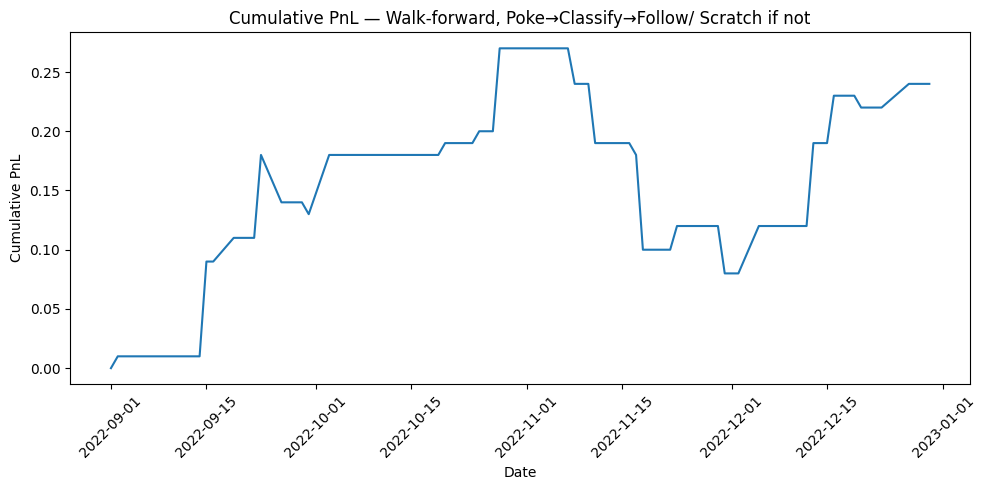

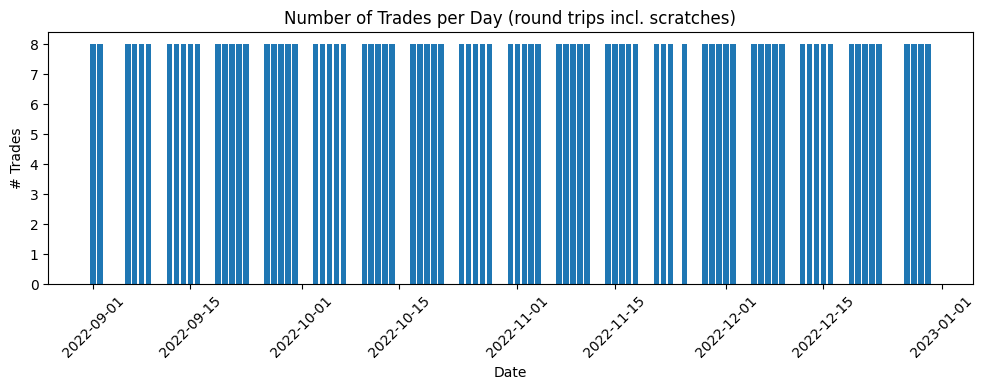

PnL by trader/source:
     trader   pnl
0        2  0.24
1  scratch  0.00


In [23]:
bt = pd.DataFrame(bt_rows).sort_values("entry_dt").reset_index(drop=True)
bt["date"] = pd.to_datetime(bt["entry_dt"]).dt.date
daily = bt.groupby("date")["pnl"].sum().reset_index().sort_values("date")
daily["cum_pnl"] = daily["pnl"].cumsum()


summary = {
    "n_trades": int(len(bt)),
    "n_days": int(bt["date"].nunique()),
    "avg_pnl_per_trade": float(bt["pnl"].mean()),
    "total_pnl": float(bt["pnl"].sum()),
    "hit_rate": float((bt["pnl"] > 0).mean()),
    "unique_reasons": bt["reason"].value_counts().to_dict(),
    "by_trader": bt["trader"].value_counts(dropna=False).to_dict(),
}
print("Backtest summary:", summary)


# Cumulative PnL
plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(daily["date"]), daily["cum_pnl"])
plt.title("Cumulative PnL — Walk-forward, Poke thenClassify then Follow/ Scratch if not")
plt.xlabel("Date"); plt.ylabel("Cumuulative PnL")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


# Trades per day
dcounts = bt.groupby("date").size().reset_index(name="n_trades")
plt.figure(figsize=(10,4))
plt.bar(pd.to_datetime(dcounts["date"]), dcounts["n_trades"])
plt.title("Number of Trades per Day including scratches")
plt.xlabel("Date"); plt.ylabel("# Trades")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


# Attribution by trader
by_trader = bt.groupby("trader")["pnl"].sum().reset_index().sort_values("pnl", ascending=False)
print("PnL by trader/source:\n", by_trader)

After a lot of trying to make the strategy work, I believe the backtest has ran as I wnated it to. But annoyingly due to the low volume of trader 2 and 6 over 97% of the pokes werent the traders I were trying to find and jsut just scratched right away (hence the very low hit rate). I spent a long long time making the backtest run as expected so it does feel wrong to restart, especially since you recommeded i spent 8-10 hours of my time on this and I am probably on around 8-9 hours so far. Instead of trying a new strategy, I am going to see if I can identify when 6 or 2 trades instead of just poking every 45 minutes from 15 minutes after market open. I do think my strategy could work if i can identify period where 2 or 6 trade the most (for exmaple maybe trader 2 enter after large volume, or when there hasnt been much volume).

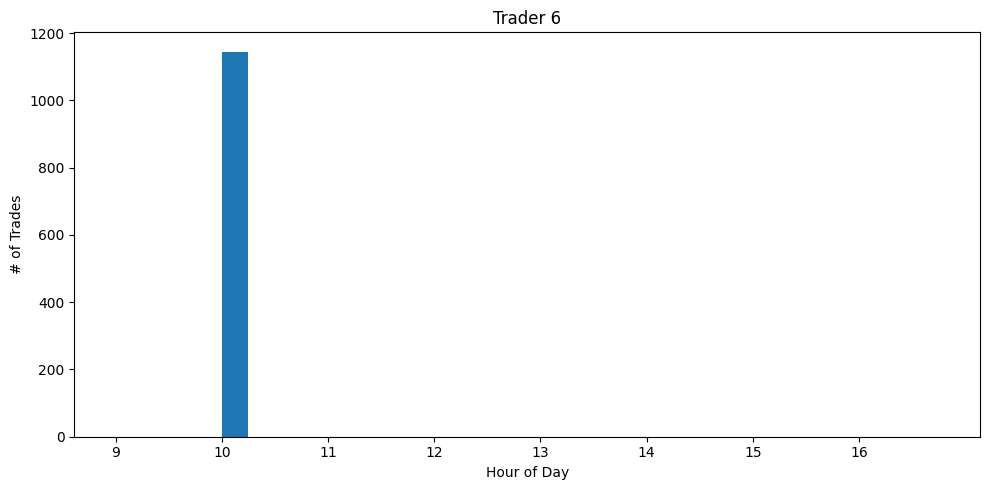

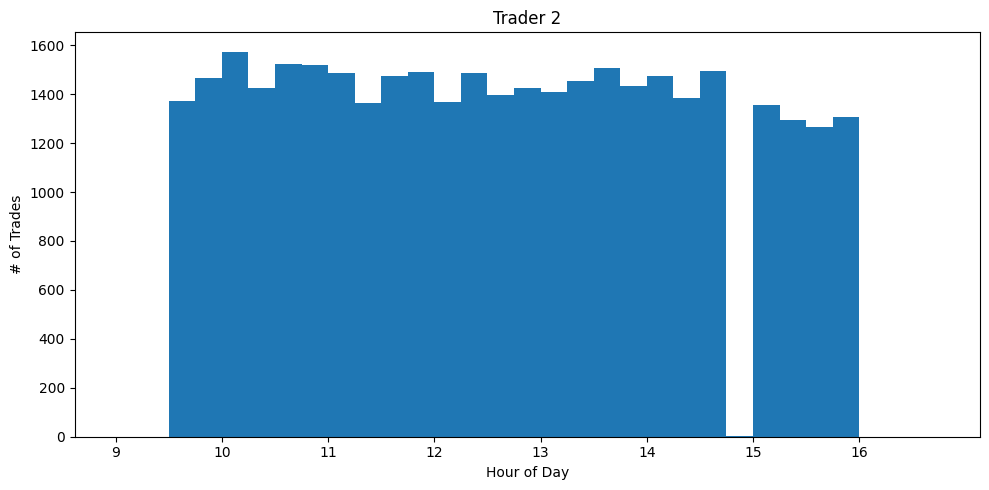

In [30]:
trader6_trades = df[(df["BuyTrader"] == 6) | (df["SellTrader"] == 6)].copy()
t6 = df[(df["BuyTrader"] == 6) | (df["SellTrader"] == 6)].copy()
t6["tod_hour"] = t6["dt"].dt.hour + t6["dt"].dt.minute/60.0

trader2_trades = df[(df["BuyTrader"] == 2) | (df["SellTrader"] == 2)].copy()
t2 = df[(df["BuyTrader"] == 2) | (df["SellTrader"] == 2)].copy()
t2["tod_hour"] = t2["dt"].dt.hour + t2["dt"].dt.minute/60.0



plt.figure(figsize=(10,5))
plt.hist(t6["tod_hour"], bins=np.arange(9,17,0.25))
plt.title("Trader 6")
plt.xlabel("Hour of Day")
plt.ylabel("# of Trades")
plt.xticks(range(9,17))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(t2["tod_hour"], bins=np.arange(9,17,0.25))
plt.title("Trader 2")
plt.xlabel("Hour of Day")
plt.ylabel("# of Trades")
plt.xticks(range(9,17))
plt.tight_layout()
plt.show()

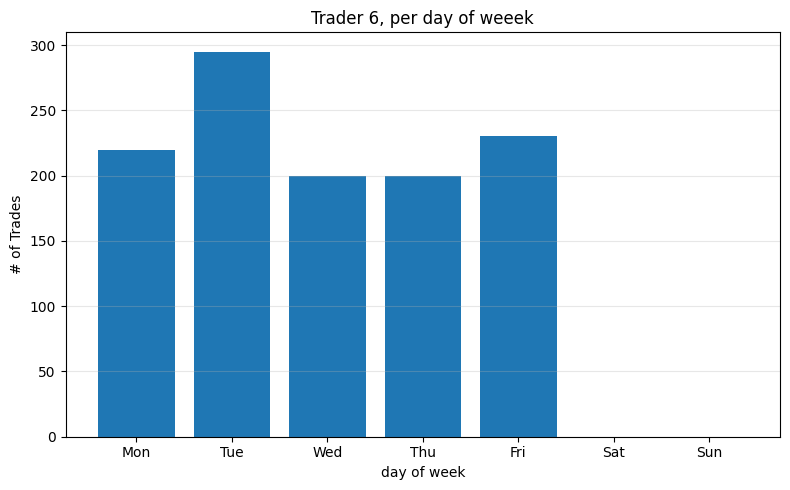

In [32]:
t6["weekday"] = t6["dt"].dt.dayofweek
day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
t6["weekday_name"] = t6["weekday"].map(day_map)

counts = t6["weekday_name"].value_counts().reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]).fillna(0)

plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values)
plt.title("Trader 6, per day of weeek")
plt.xlabel("day of week")
plt.ylabel("# of Trades")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Ok ok perfect. it looks like trader 6 inly tardes between 10 and 10:15 each day. If i can time my pokes with this, i might be able to latch onto trader 6s profitability. trader 2 seems to trade all hours.

In [39]:
TARGET_WINDOW_START = "10:00:00"   # window start (HH:MM:SS)
TARGET_WINDOW_END   = "10:15:00"   # window end
TARGET_POKE_INTERVAL_SEC = 60    #every minute within the window

from datetime import time

def generate_target_window_pokes(day_date, trading_day_df):
    """
    Returns a sorted list of datetimes to attempt targeted pokes for trader 6.
    We'll schedule discrete nominal poke-times at 10:00, 10:05, 10:10 (or derived from config).
    """
    day_str = str(day_date)
    start_dt = pd.to_datetime(day_str + " " + TARGET_WINDOW_START)
    end_dt   = pd.to_datetime(day_str + " " + TARGET_WINDOW_END)
    times = []
    t = start_dt
    while t < end_dt:
        times.append(t)
        t += pd.Timedelta(seconds=TARGET_POKE_INTERVAL_SEC)
    return times

bt_rows = []

for m in TRADE_MONTHS:
    train6 = labels_6[(labels_6["month"] < m)].dropna(subset=FEAT_COLS_TRAIN + ["y","pnl_follow"])
    train2 = labels_2[(labels_2["month"] < m)].dropna(subset=FEAT_COLS_TRAIN + ["y","pnl_follow"])

    clf6 = fit_classifier(train6)
    clf2 = fit_classifier(train2)
    tau6 = tau_from_train(train6, clf6) if clf6 else 0.5
    tau2 = tau_from_train(train2, clf2) if clf2 else 0.5

    for d, g in df_feat[df_feat["month"] == m].groupby("day"):
        if d not in day_cut_dt: continue
        cut_dt = day_cut_dt[d]
        g = g.sort_values("dt").copy()

        poke_times = generate_target_window_pokes(d, g)
        print(poke_times)
        next_poke_idx = 0
        window_retries = 0

        buys_used = 0
        sells_used = 0
        entries: List[Position] = []

        for _, row in g.iterrows():
            dt = row["dt"]; px = float(row[price_col])

            # manage existing positions
            entries, closed_now = manage_positions(entries, dt, px, cut_dt)
            for c in closed_now:
                pnl_raw = (c["exit_px"] - c["entry_px"]) if c["side"] == "long" else (c["entry_px"] - c["exit_px"])
                bt_rows.append({**c, "pnl": apply_costs(pnl_raw)})

            if dt >= cut_dt:
                continue

            # window active?
            tstart = pd.to_datetime(TARGET_WINDOW_START).time()
            tend   = pd.to_datetime(TARGET_WINDOW_END).time()
            window_active = (dt.time() >= tstart) and (dt.time() < tend)

            # should we poke now?
            should_poke = False
            if window_active and (window_retries < MAX_WINDOW_RETRIES):
                should_poke = True
            elif (next_poke_idx < len(poke_times)) and (dt >= poke_times[next_poke_idx]):
                should_poke = True
                next_poke_idx += 1

            if not should_poke:
                continue

            # capacity?
            if (buys_used >= MAX_BUYS_PER_DAY) and (sells_used >= MAX_SELLS_PER_DAY):
                continue

            # choose poke side to guarantee fill proxy
            has_buyer = pd.notna(row[buy_col])
            has_seller = pd.notna(row[sell_col])
            poke_side = None
            if has_buyer and sells_used < MAX_SELLS_PER_DAY:
                poke_side = "short"
            elif has_seller and buys_used < MAX_BUYS_PER_DAY:
                poke_side = "long"
            else:
                continue

            rv_here = float(row.get("rv_300s", np.nan)) if pd.notna(row.get("rv_300s", np.nan)) else RV_FALLBACK
            tp_px, sl_px = vol_scaled_targets(rv_here, px)
            entries.append(Position(side=poke_side, entry_dt=dt, entry_px=px, trader=None,
                                    rv_at_entry=rv_here, tp_px=tp_px, sl_px=sl_px))
            if poke_side == "long": buys_used += 1
            else: sells_used += 1

            # reveal counterparty & decide keep vs scratch
            revealed_id = 6 if (row[buy_col] == 6 or row[sell_col] == 6) else (2 if (row[buy_col] == 2 or row[sell_col] == 2) else None)
            keep = False
            if revealed_id == 6 and clf6 is not None:
                p6, side6 = score_trader_row(row, 6, clf6)
                if (p6 is not None) and (p6 >= tau6):
                    if (side6 == "buy" and poke_side == "long") or (side6 == "sell" and poke_side == "short"):
                        keep = True
                if keep: entries[-1].trader = 6

            elif revealed_id == 2 and clf2 is not None:
                p2, side2 = score_trader_row(row, 2, clf2)
                if (p2 is not None) and (p2 >= tau2):
                    if (side2 == "buy" and poke_side == "long") or (side2 == "sell" and poke_side == "short"):
                        keep = True
                if keep: entries[-1].trader = 2

            if not keep:
                # immediate scratch at current price
                pos = entries.pop()
                pnl_raw = (px - pos.entry_px) if pos.side == "long" else (pos.entry_px - px)
                bt_rows.append({
                    "day": d, "entry_dt": pos.entry_dt, "exit_dt": dt, "side": pos.side,
                    "entry_px": pos.entry_px, "exit_px": px, "trader": "scratch",
                    "reason": "scratch", "pnl": apply_costs(pnl_raw)
                })
                if window_active:
                    window_retries += 1
            else:
                # success: prevent more window pokes if you want (we stop further retries)
                window_retries = MAX_WINDOW_RETRIES

        # force close at cutoff
        exit_row = g[g["dt"] >= cut_dt].head(1)
        if not exit_row.empty and len(entries):
            exit_dt = exit_row["dt"].iloc[0]
            exit_px = float(exit_row[price_col].iloc[0])
            for pos in entries:
                pnl_raw = (exit_px - pos.entry_px) if pos.side == "long" else (pos.entry_px - exit_px)
                bt_rows.append({
                    "day": d, "entry_dt": pos.entry_dt, "exit_dt": exit_dt, "side": pos.side,
                    "entry_px": pos.entry_px, "exit_px": exit_px, "trader": pos.trader,
                    "reason": "cutoff_force", "pnl": apply_costs(pnl_raw)
                })

[Timestamp('2022-09-01 10:00:00'), Timestamp('2022-09-01 10:01:00'), Timestamp('2022-09-01 10:02:00'), Timestamp('2022-09-01 10:03:00'), Timestamp('2022-09-01 10:04:00'), Timestamp('2022-09-01 10:05:00'), Timestamp('2022-09-01 10:06:00'), Timestamp('2022-09-01 10:07:00'), Timestamp('2022-09-01 10:08:00'), Timestamp('2022-09-01 10:09:00'), Timestamp('2022-09-01 10:10:00'), Timestamp('2022-09-01 10:11:00'), Timestamp('2022-09-01 10:12:00'), Timestamp('2022-09-01 10:13:00'), Timestamp('2022-09-01 10:14:00')]
[Timestamp('2022-09-02 10:00:00'), Timestamp('2022-09-02 10:01:00'), Timestamp('2022-09-02 10:02:00'), Timestamp('2022-09-02 10:03:00'), Timestamp('2022-09-02 10:04:00'), Timestamp('2022-09-02 10:05:00'), Timestamp('2022-09-02 10:06:00'), Timestamp('2022-09-02 10:07:00'), Timestamp('2022-09-02 10:08:00'), Timestamp('2022-09-02 10:09:00'), Timestamp('2022-09-02 10:10:00'), Timestamp('2022-09-02 10:11:00'), Timestamp('2022-09-02 10:12:00'), Timestamp('2022-09-02 10:13:00'), Timestamp('2

Backtest summary: {'n_trades': 840, 'n_days': 84, 'avg_pnl_per_trade': 0.00029761904761899685, 'total_pnl': 0.24999999999995737, 'hit_rate': 0.047619047619047616, 'unique_reasons': {'scratch': 770, 'TP/SL/time/cutoff': 70}, 'by_trader': {'scratch': 770, 2: 43, 6: 27}}


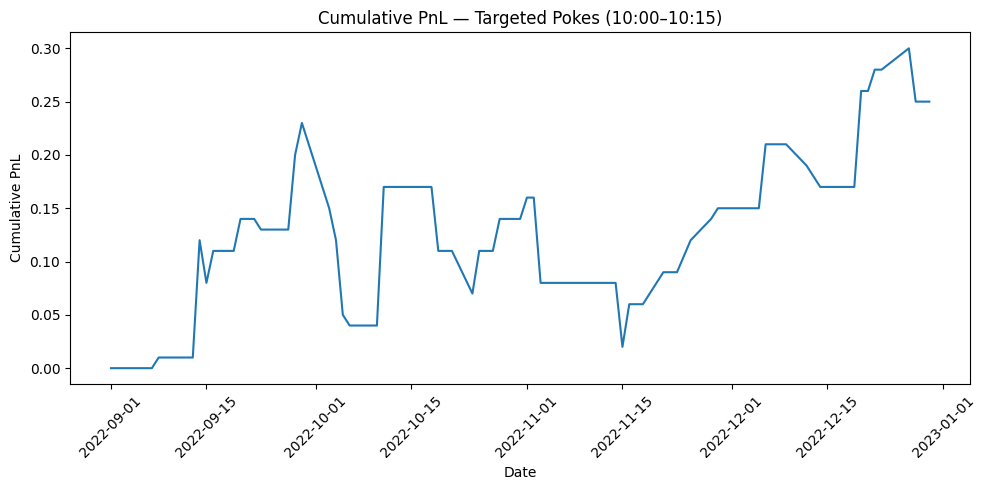

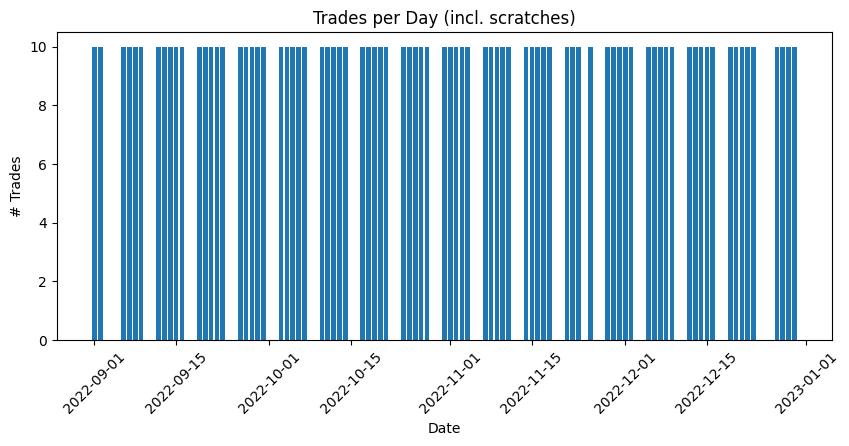

PnL by trader/source:
     trader   pnl
1        6  0.32
2  scratch  0.00
0        2 -0.07


In [41]:
bt = pd.DataFrame(bt_rows).sort_values("entry_dt").reset_index(drop=True)

bt["date"] = pd.to_datetime(bt["entry_dt"]).dt.date
daily = bt.groupby("date")["pnl"].sum().reset_index().sort_values("date")
daily["cum_pnl"] = daily["pnl"].cumsum()

summary = {
    "n_trades": int(len(bt)),
    "n_days": int(bt["date"].nunique()),
    "avg_pnl_per_trade": float(bt["pnl"].mean()),
    "total_pnl": float(bt["pnl"].sum()),
    "hit_rate": float((bt["pnl"] > 0).mean()),
    "unique_reasons": bt["reason"].value_counts().to_dict(),
    "by_trader": bt["trader"].value_counts(dropna=False).to_dict(),
}
print("Backtest summary:", summary)

# Plots
plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(daily["date"]), daily["cum_pnl"])
plt.title("Cumulative PnL — Targeted Pokes (10:00–10:15)")
plt.xlabel("Date"); plt.ylabel("Cumulative PnL")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# Trades per day
dcounts = bt.groupby("date").size().reset_index(name="n_trades")
plt.figure(figsize=(10,4))
plt.bar(pd.to_datetime(dcounts["date"]), dcounts["n_trades"])
plt.title("Trades per Day (incl. scratches)")
plt.xlabel("Date")
plt.ylabel("# Trades")
plt.xticks(rotation=45); plt.show()

# Attribution
by_trader = bt.groupby("trader")["pnl"].sum().reset_index().sort_values("pnl", ascending=False)
print("PnL by trader/source:\n", by_trader)

Again, this didnt really work. I did start picking up on trader 6s trades but still  {'scratch': 770, 2: 43, 6: 27} being the split between scratch, trader 2 and trader 6 isnt very good. I think I have found a mistake in my logic. When I poke the market I am going against the trader that is revealed to me. I want to be following 6. This makes it difficult due to the trade constaints (if i poke 6, i am against them. If i want to follow six i need to go back to neutral and then go with 6, then eventually go back to neutral. That is 4 trades used for one 'cycle').
* Right now I am barely trading with 2 or 6 and when I do I am going against them when I should be following them. With this in mind it isnt exactly surprising the strategy isn't profitable.


New Idea (if i have time to finish it before i need to submit this notebook:
* I want more signals. The previous strategy had a small percentage of times I 'found' the correct trader.

Short term order flow classifier
1. When people are generally going long and volatility stays the same

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from dataclasses import dataclass
from datetime import timedelta

TIME_COL_CANDS = ["TimeOfDay", "time", "Time"]
PRICE_COL_CANDS = ["Spot", "Price", "spot", "price", "Spot_Price"]
BUY_COL_CANDS = ["BuyTrader"]
SELL_COL_CANDS = ["SellTrader"]
CSV_PATH = "/content/Data Exercise - Trade Data.csv"

W_SHORT = 60
W_MED = 300
W_LONG = 900

HORIZON_SEC = 300

LAST_MINUTES_CUTOFF = 30  # no new entries after last 30 minutes of each day
MAX_ENTRIES_PER_DAY = 10  # cap total signals per day

# Signal thresholds
P_LONG = 0.55
P_SHORT = 0.45

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=300))
])

OOS_MONTHS = [9, 10, 11, 12]

In [47]:
df = pd.read_csv(CSV_PATH)
# Basic column detection
price_col = next((c for c in PRICE_COL_CANDS if c in df.columns), None)
if price_col is None:
    raise ValueError("Price column not found. Check PRICE_COL_CANDS.")
buy_col = next((c for c in BUY_COL_CANDS if c in df.columns), None)
if buy_col is None:
    buy_col = next((c for c in df.columns if "buy" in c.lower()), None)
sell_col = next((c for c in SELL_COL_CANDS if c in df.columns), None)
if sell_col is None:
    sell_col = next((c for c in df.columns if "sell" in c.lower()), None)

df["Date"] = pd.to_datetime(df["Date"])
time_col = next((c for c in TIME_COL_CANDS if c in df.columns), None)
if time_col is not None:
    try:
        df[time_col] = pd.to_datetime(df[time_col]).dt.time
    except Exception:
        pass
    df["dt"] = pd.to_datetime(df["Date"].astype(str) + " " + df[time_col].astype(str))
else:
    df["dt"] = df["Date"]

df = df.sort_values("dt").reset_index(drop=True)
df["day"] = df["dt"].dt.date
df["month"] = df["dt"].dt.month

/tmp/ipython-input-757656292.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col]).dt.time


In [49]:
def build_flow_features_per_day(g: pd.DataFrame) -> pd.DataFrame:
    g = g.copy().sort_values("dt")
    g = g.set_index("dt")
    px = g[price_col].astype(float)

    # did price go up or down +1, -1 classified
    signed = np.where(g[buy_col].astype(str) < g[sell_col].astype(str), 1.0, -1.0)
    signed_s = pd.Series(signed, index=g.index)

    ones = pd.Series(1.0, index=g.index)
    # rolling counts / velocity
    c_short = ones.rolling(f"{W_SHORT}s").sum()
    c_med = ones.rolling(f"{W_MED}s").sum()
    vel_short = c_short / max(W_SHORT, 1)
    vel_med = c_med / max(W_MED, 1)

    # buy/sell counts via signed decomposition
    b_short = signed_s.clip(lower=0).rolling(f"{W_SHORT}s").sum()
    s_short = (-signed_s).clip(lower=0).rolling(f"{W_SHORT}s").sum()
    b_med = signed_s.clip(lower=0).rolling(f"{W_MED}s").sum()
    s_med = (-signed_s).clip(lower=0).rolling(f"{W_MED}s").sum()

    imb_short = (b_short - s_short) / (b_short + s_short + 1e-9)
    imb_med = (b_med - s_med) / (b_med + s_med + 1e-9)

    # price features, vol, returns etc
    ret_60 = px.pct_change().rolling("60s").sum()
    ret_300 = px.pct_change().rolling("300s").sum()
    r5 = px.pct_change().rolling("5s").sum()
    rv_300 = r5.rolling("300s").std()

    vwap = px.expanding().mean()
    dist_to_vwap = (px - vwap) / vwap

    start = g.index.min()
    end = g.index.max()
    total = (end - start).total_seconds() if pd.notna(end) and pd.notna(start) else 1.0
    pos_in_day = (g.index - start).total_seconds() / max(total, 1.0)

    out = pd.DataFrame({
        "dt": g.index,
        price_col: px.values,
        "imb_short": imb_short.values,
        "imb_med": imb_med.values,
        "vel_short": vel_short.values,
        "vel_med": vel_med.values,
        "ret_60": ret_60.values,
        "ret_300": ret_300.values,
        "rv_300": rv_300.values,
        "dist_to_vwap": dist_to_vwap.values,
        "pos_in_day": pos_in_day.values,
    }).reset_index(drop=True)

    # FUTURE price at dt + HORIZON_SEC within the same day via merge_asof
    target_times = out["dt"] + pd.to_timedelta(HORIZON_SEC, unit="s")
    future_df = pd.DataFrame({"t_target": target_times})
    base = out[["dt", price_col]].rename(columns={"dt": "t_now", price_col: "px_now"})
    fut = pd.merge_asof(future_df.sort_values("t_target"),
                        base.sort_values("t_now"),
                        left_on="t_target", right_on="t_now",
                        direction="forward")
    out["px_future"] = fut["px_now"].values
    out["fut_ret"] = out["px_future"] - out[price_col]

    out["day"] = pd.to_datetime(out["dt"]).dt.date
    out["month"] = pd.to_datetime(out["dt"]).dt.month
    return out

In [50]:
feat = df.groupby("day", group_keys=False).apply(build_flow_features_per_day)
feat = feat.sort_values("dt").reset_index(drop=True)
feat["y"] = (feat["fut_ret"] > 0).astype(int) # future returns up or down
cutoff_map = (feat.groupby("day")["dt"].max() - pd.Timedelta(minutes=LAST_MINUTES_CUTOFF)).to_dict() # cut off trading in last 30 mins

FEAT_COLS = ["imb_short", "imb_med", "vel_short", "vel_med", "ret_60", "ret_300", "rv_300", "dist_to_vwap", "pos_in_day"]

/tmp/ipython-input-3204456786.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feat = df.groupby("day", group_keys=False).apply(build_flow_features_per_day)


In [51]:
bt = []

for m in OOS_MONTHS:
    train = feat[(feat["month"] < m)].dropna(subset=FEAT_COLS + ["y"])
    test = feat[feat["month"] == m].copy()

    if train.empty or test.empty:
        continue

    X = train[FEAT_COLS].values
    y = train["y"].values
    pipe.fit(X, y)

    # quick train AUC/ACC (for sanity)
    try:
        p_tr = pipe.predict_proba(X)[:, 1]
        auc_tr = roc_auc_score(y, p_tr)
        acc_tr = accuracy_score(y, (p_tr >= 0.5).astype(int))
        print(f"Month {m}: train AUC={auc_tr:.3f} acc={acc_tr:.3f} n={len(train)}")
    except Exception:
        pass

    # Trade each day of month m
    for d, g in test.groupby("day"):
        cut_dt = cutoff_map.get(d, None)
        if cut_dt is None:
            continue
        g = g.sort_values("dt").copy()
        entries_used = 0

        for _, row in g.iterrows():
            dt = row["dt"]
            if dt >= cut_dt:
                break
            if entries_used >= MAX_ENTRIES_PER_DAY:
                break

            # Need a valid future price to realize PnL
            if pd.isna(row["px_future"]):
                continue

            x = row[FEAT_COLS].values.reshape(1, -1)
            p = pipe.predict_proba(x)[:, 1][0]

            if p >= P_LONG:
                pnl = row["px_future"] - row[price_col]
                bt.append({"day": d, "entry_dt": dt, "side": "long", "p": p, "pnl": pnl})
                entries_used += 1
            elif p <= P_SHORT:
                pnl = row[price_col] - row["px_future"]
                bt.append({"day": d, "entry_dt": dt, "side": "short", "p": p, "pnl": pnl})
                entries_used += 1

results = pd.DataFrame(bt)


Month 9: train AUC=0.557 acc=0.546 n=79245
Month 10: train AUC=0.556 acc=0.545 n=89143
Month 11: train AUC=0.557 acc=0.545 n=99224
Month 12: train AUC=0.556 acc=0.545 n=109310


Flow strategy summary: {'n_trades': 840, 'n_days': 84, 'avg_pnl_per_trade': 0.015571428571428772, 'total_pnl': 13.080000000000169, 'hit_rate': 0.5488095238095239, 'long_short_split': {'long': 453, 'short': 387}}


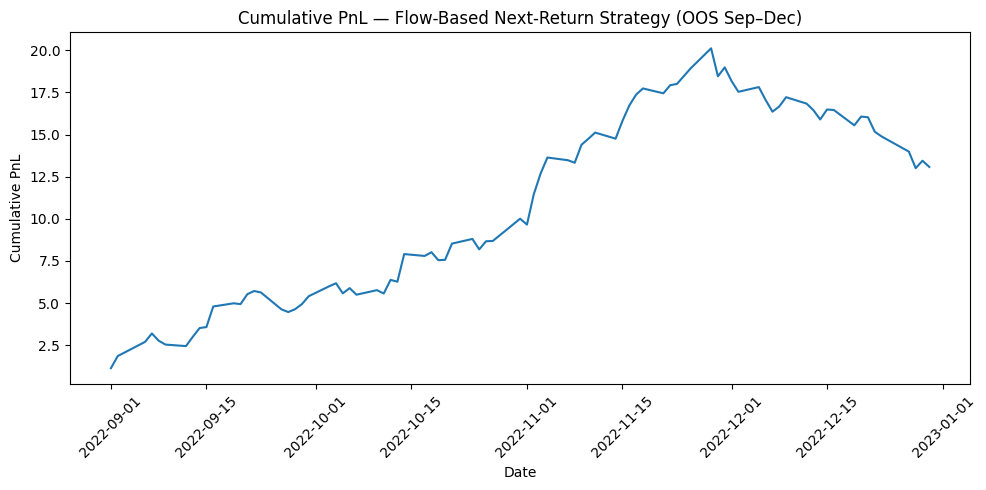

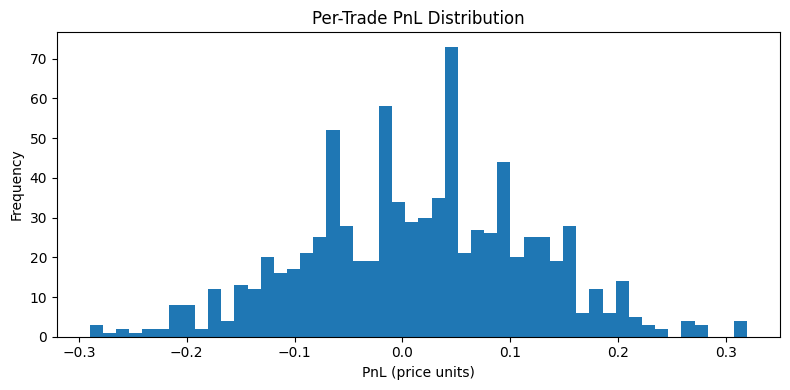

,day,entry_dt,side,p,pnl,date
0,2022-09-01,2022-09-01 09:32:40,long,0.581687,-0.02,2022-09-01
1,2022-09-01,2022-09-01 09:33:39,long,0.590265,0.11,2022-09-01
2,2022-09-01,2022-09-01 09:33:45,long,0.587154,0.10,2022-09-01
3,2022-09-01,2022-09-01 09:34:00,long,0.591237,0.14,2022-09-01
4,2022-09-01,2022-09-01 09:34:40,long,0.583896,0.09,2022-09-01
5,2022-09-01,2022-09-01 09:35:21,long,0.550685,0.09,2022-09-01
6,2022-09-01,2022-09-01 09:40:22,short,0.431009,0.32,2022-09-01
7,2022-09-01,2022-09-01 09:40:44,short,0.428398,0.31,2022-09-01
8,2022-09-01,2022-09-01 09:44:50,short,0.422183,0.18,2022-09-01
9,2022-09-01,2022-09-01 09:46:58,long,0.556243,-0.18,2022-09-01


In [52]:
results["date"] = pd.to_datetime(results["entry_dt"]).dt.date
daily = results.groupby("date")["pnl"].sum().reset_index().sort_values("date")
daily["cum_pnl"] = daily["pnl"].cumsum()

summary = {
    "n_trades": int(len(results)),
    "n_days": int(results["date"].nunique()),
    "avg_pnl_per_trade": float(results["pnl"].mean()),
    "total_pnl": float(results["pnl"].sum()),
    "hit_rate": float((results["pnl"] > 0).mean()),
    "long_short_split": results["side"].value_counts().to_dict()
}
print("Flow strategy summary:", summary)

# Plot cumulative PnL
plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(daily["date"]), daily["cum_pnl"])
plt.title("Cumulative PnL — Flow-Based Next-Return Strategy (OOS Sep–Dec)")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Per-trade PnL histogram
plt.figure(figsize=(8,4))
plt.hist(results["pnl"].dropna(), bins=50)
plt.title("Per-Trade PnL Distribution")
plt.xlabel("PnL (price units)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Print head of trades
results.head(10)

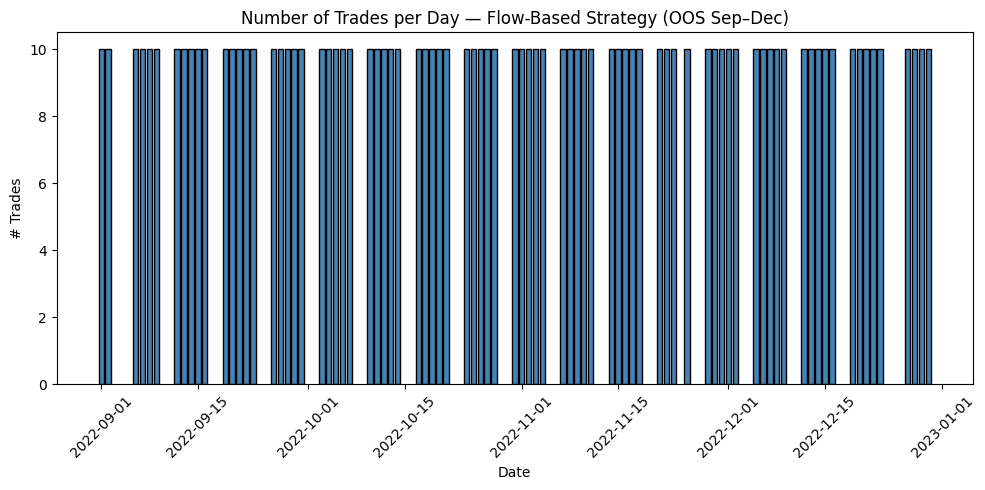

In [54]:
trades_per_day = results.groupby("date").size().reset_index(name="n_trades")
plt.figure(figsize=(10, 5))
plt.bar(trades_per_day["date"], trades_per_day["n_trades"], color="steelblue", edgecolor="black")
plt.title("Number of Trades per Day — Flow-Based Strategy (OOS Sep–Dec)")
plt.xlabel("Date")
plt.ylabel("# Trades")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()